# 04 – Análise Exploratória e Visualização

**Objetivo:** Realizar a análise exploratória da base de modelagem (`base_modelagem.csv`), cobrindo:
- Estatísticas descritivas gerais
- Análise de variáveis qualitativas (frequências, tabelas de contingência)
- Análise de variáveis quantitativas (idade, tempo de permanência, tempo de sobrevida)
- Visualizações (histograma, boxplot, barras, mapa de calor)

**Base:** `data/processed/base_modelagem.csv`

## 0. Imports e Configurações

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = Path('../data/processed/base_modelagem.csv')
FIG_PATH  = Path('../reports/figures')
FIG_PATH.mkdir(parents=True, exist_ok=True)

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## 1. Carregamento e Pré-processamento Inicial

In [6]:
df = pd.read_csv(DATA_PATH, low_memory=False).copy()

# ----- Datas -----
df['data_internacao'] = pd.to_datetime(df['data_internacao'], format='%Y%m%d', errors='coerce')
df['data_saida']      = pd.to_datetime(df['data_saida'],      format='%Y%m%d', errors='coerce')

# Tempo de sobrevida hospitalar (dias entre entrada e saída)
df['tempo_sobrevida'] = (df['data_saida'] - df['data_internacao']).dt.days

# ----- Mapeamentos de categorias -----
df['desfecho_label']  = df['indicador_obito'].map({0: 'Alta', 1: 'Óbito'})
df['sexo_label']      = df['sexo'].map({1: 'Masculino', 3: 'Feminino'})
df['raca_label']      = df['raca_cor'].map({
    1: 'Branca', 2: 'Preta', 3: 'Parda', 4: 'Amarela', 5: 'Indígena'
})
df['carater_label']   = df['carater_internacao'].map({1: 'Eletivo', 2: 'Urgência'})

# Natureza jurídica — agrupamento em macrocategorias IBGE
# Valores únicos na base: 1023, 1031, 1112, 1120, 1155, 1210, 1228, 1244, 1279
#                         2011, 2062, 3069, 3999
def macro_natureza(cod):
    if pd.isna(cod):
        return 'Não informado'
    cod = int(cod)
    if 2000 <= cod <= 4999:
        return 'Público'
    elif cod in (5045, 5053):
        return 'OS/OSCIP'
    elif cod in (5010, 5029, 5037):
        return 'Privado s/ fins lucrativos'
    elif cod >= 5000:
        return 'Privado c/ fins lucrativos'
    elif 1000 <= cod <= 1999:
        return 'Privado c/ fins lucrativos'
    else:
        return 'Outro'

df['natureza_label'] = df['natureza_juridica'].apply(macro_natureza)

# ----- Faixa etária -----
bins   = [0, 39, 49, 59, 69, 79, 200]
labels = ['<40', '40–49', '50–59', '60–69', '70–79', '80+']
df['faixa_etaria'] = pd.cut(df['idade'], bins=bins, labels=labels, right=True)

# ----- Filtro adultos (garante consistência) -----
df = df[df['idade'] >= 18].copy()

print(f'Base carregada: {df.shape[0]:,} internações | {df.shape[1]} colunas')
df[['desfecho_label','sexo_label','raca_label','carater_label',
    'natureza_label','faixa_etaria','tempo_sobrevida']].head(3)


Base carregada: 380,591 internações | 670 colunas


,desfecho_label,sexo_label,raca_label,carater_label,natureza_label,faixa_etaria,tempo_sobrevida
0,Alta,Feminino,Preta,Urgência,Privado c/ fins lucrativos,50–59,28
1,Óbito,Feminino,NaN,Urgência,Privado c/ fins lucrativos,60–69,12
2,Óbito,Feminino,NaN,Urgência,Privado c/ fins lucrativos,60–69,8


## 2. Estatísticas Descritivas Gerais

In [7]:
n_internacoes = len(df)
n_hospitais   = df['codigo_cnes'].nunique()
n_obitos      = df['indicador_obito'].sum()
taxa_letali   = (n_obitos / n_internacoes) * 100

print('=' * 50)
print('  DIMENSÃO DA BASE PÓS-MERGE')
print('=' * 50)
print(f'  Nº de internações (pacientes) : {n_internacoes:>8,}')
print(f'  Nº de hospitais (CNES únicos) : {n_hospitais:>8,}')
print()
print('  DISTRIBUIÇÃO DO DESFECHO')
print('-' * 50)
dest = df['desfecho_label'].value_counts()
dest_pct = df['desfecho_label'].value_counts(normalize=True) * 100
for cat in dest.index:
    print(f'  {cat:<8}: {dest[cat]:>6,}  ({dest_pct[cat]:5.2f}%)')
print()
print(f'  TAXA DE LETALIDADE HOSPITALAR : {taxa_letali:.2f}%')
print('=' * 50)

  DIMENSÃO DA BASE PÓS-MERGE
  Nº de internações (pacientes) :  380,591
  Nº de hospitais (CNES únicos) :      504

  DISTRIBUIÇÃO DO DESFECHO
--------------------------------------------------
  Alta    : 344,680  (90.56%)
  Óbito   : 35,911  ( 9.44%)

  TAXA DE LETALIDADE HOSPITALAR : 9.44%


## 3. Análise de Variáveis Qualitativas

### 3.1 Frequências absolutas e relativas

In [8]:
def tabela_freq(serie, titulo):
    """Retorna DataFrame com frequência absoluta e relativa."""
    freq  = serie.value_counts(dropna=False)
    pct   = serie.value_counts(normalize=True, dropna=False) * 100
    tbl   = pd.DataFrame({'n': freq, '%': pct.round(2)})
    tbl.index.name = titulo
    return tbl

variaveis_quali = {
    'Sexo':                  'sexo_label',
    'Raça/Cor':              'raca_label',
    'Caráter do atendimento':'carater_label',
    'Natureza jurídica':     'natureza_label',
}

for titulo, coluna in variaveis_quali.items():
    print(f'\n--- {titulo} ---')
    display(tabela_freq(df[coluna], titulo))


--- Sexo ---


,n,%
Sexo,,
Masculino,242504,63.72
Feminino,138087,36.28



--- Raça/Cor ---


,n,%
Raça/Cor,,
Branca,220347,57.90
Parda,96529,25.36
NaN,41751,10.97
Preta,18338,4.82
Amarela,3593,0.94
Indígena,33,0.01



--- Caráter do atendimento ---


,n,%
Caráter do atendimento,,
Urgência,344764,90.59
Eletivo,35827,9.41



--- Natureza jurídica ---


,n,%
Natureza jurídica,,
Público,206124,54.16
Privado c/ fins lucrativos,174467,45.84


### 3.2 Tabelas de contingência (desfecho × variável)

In [9]:
def contingencia(df, var_linha, var_col='desfecho_label', normalize='index'):
    """Tabela de contingência com % por linha."""
    ct = pd.crosstab(
        df[var_linha], df[var_col],
        margins=True, margins_name='Total'
    )
    ct_pct = pd.crosstab(
        df[var_linha], df[var_col],
        normalize=normalize
    ) * 100
    return ct, ct_pct.round(2)

# Desfecho × Sexo
print('=== Desfecho × Sexo ===')
ct, ct_pct = contingencia(df, 'sexo_label')
display(ct)
print('% por linha:')
display(ct_pct)

# Desfecho × Faixa etária
print('\n=== Desfecho × Faixa Etária ===')
ct2, ct_pct2 = contingencia(df, 'faixa_etaria')
display(ct2)
print('% por linha:')
display(ct_pct2)

# Desfecho × Caráter do atendimento
print('\n=== Desfecho × Caráter do Atendimento ===')
ct3, ct_pct3 = contingencia(df, 'carater_label')
display(ct3)
print('% por linha:')
display(ct_pct3)

# Desfecho × Raça/Cor
print('\n=== Desfecho × Raça/Cor ===')
ct4, ct_pct4 = contingencia(df, 'raca_label')
display(ct4)
print('% por linha:')
display(ct_pct4)

=== Desfecho × Sexo ===


desfecho_label,Alta,Óbito,Total
sexo_label,,,
Feminino,122533,15554,138087
Masculino,222147,20357,242504
Total,344680,35911,380591


% por linha:


desfecho_label,Alta,Óbito
sexo_label,,
Feminino,88.74,11.26
Masculino,91.61,8.39



=== Desfecho × Faixa Etária ===


...

desfecho_label,Alta,Óbito
carater_label,,
Eletivo,95.77,4.23
Urgência,90.02,9.98



=== Desfecho × Raça/Cor ===


desfecho_label,Alta,Óbito,Total
raca_label,,,
Amarela,3237,356,3593
Branca,199288,21059,220347
Indígena,31,2,33
Parda,88456,8073,96529
Preta,16757,1581,18338
Total,307769,31071,338840


% por linha:


desfecho_label,Alta,Óbito
raca_label,,
Amarela,90.09,9.91
Branca,90.44,9.56
Indígena,93.94,6.06
Parda,91.64,8.36
Preta,91.38,8.62


## 4. Análise de Variáveis Quantitativas

### 4.1 Idade

In [10]:
print('=== Estatísticas de Idade ===')
stats_idade = df['idade'].describe(percentiles=[0.25, 0.5, 0.75])
print(f"  Média    : {stats_idade['mean']:.2f} anos")
print(f"  Mediana  : {stats_idade['50%']:.1f} anos")
print(f"  Desvio-p : {stats_idade['std']:.2f}")
print(f"  Q1       : {stats_idade['25%']:.1f}")
print(f"  Q3       : {stats_idade['75%']:.1f}")
print(f"  Mín      : {stats_idade['min']:.0f}")
print(f"  Máx      : {stats_idade['max']:.0f}")

print('\n--- Por desfecho ---')
display(df.groupby('desfecho_label')['idade'].describe(percentiles=[0.25, 0.5, 0.75]).round(2))

=== Estatísticas de Idade ===
  Média    : 62.81 anos
  Mediana  : 63.0 anos
  Desvio-p : 12.33
  Q1       : 55.0
  Q3       : 71.0
  Mín      : 18
  Máx      : 99

--- Por desfecho ---


,count,mean,std,min,25%,50%,75%,max
desfecho_label,,,,,,,,
Alta,344680.0,62.12,12.13,18.0,54.0,62.0,70.0,99.0
Óbito,35911.0,69.43,12.20,18.0,61.0,70.0,78.0,99.0


### 4.2 Tempo de permanência

In [11]:
print('=== Estatísticas de Tempo de Permanência (dias) ===')
stats_perm = df['dias_permanencia'].describe(percentiles=[0.25, 0.5, 0.75])
print(f"  Média    : {stats_perm['mean']:.2f} dias")
print(f"  Mediana  : {stats_perm['50%']:.1f} dias")
print(f"  Desvio-p : {stats_perm['std']:.2f}")
print(f"  Q1 / Q3  : {stats_perm['25%']:.1f} / {stats_perm['75%']:.1f}")

print('\n--- Por desfecho ---')
display(df.groupby('desfecho_label')['dias_permanencia'].describe(percentiles=[0.25, 0.5, 0.75]).round(2))

=== Estatísticas de Tempo de Permanência (dias) ===
  Média    : 7.16 dias
  Mediana  : 4.0 dias
  Desvio-p : 8.61
  Q1 / Q3  : 2.0 / 9.0

--- Por desfecho ---


,count,mean,std,min,25%,50%,75%,max
desfecho_label,,,,,,,,
Alta,344680.0,7.26,8.49,0.0,2.0,5.0,9.0,247.0
Óbito,35911.0,6.18,9.63,0.0,1.0,2.0,8.0,188.0


### 4.3 Tempo de sobrevida hospitalar

In [12]:
print('=== Tempo de Sobrevida Hospitalar (data_saida – data_internacao, em dias) ===')
print(f"  Valores ausentes : {df['tempo_sobrevida'].isna().sum()}")
stats_sob = df['tempo_sobrevida'].describe(percentiles=[0.25, 0.5, 0.75])
print(f"  Média    : {stats_sob['mean']:.2f} dias")
print(f"  Mediana  : {stats_sob['50%']:.1f} dias")
print(f"  Desvio-p : {stats_sob['std']:.2f}")
print(f"  Q1 / Q3  : {stats_sob['25%']:.1f} / {stats_sob['75%']:.1f}")

print('\n--- Por desfecho ---')
display(df.groupby('desfecho_label')['tempo_sobrevida'].describe(percentiles=[0.25, 0.5, 0.75]).round(2))

=== Tempo de Sobrevida Hospitalar (data_saida – data_internacao, em dias) ===
  Valores ausentes : 0
  Média    : 7.16 dias
  Mediana  : 4.0 dias
  Desvio-p : 8.61
  Q1 / Q3  : 2.0 / 9.0

--- Por desfecho ---


,count,mean,std,min,25%,50%,75%,max
desfecho_label,,,,,,,,
Alta,344680.0,7.26,8.49,0.0,2.0,5.0,9.0,247.0
Óbito,35911.0,6.18,9.64,0.0,1.0,2.0,8.0,188.0


### 4.4 Tabelas Consolidadas (Formatadas para o TCC)

In [15]:
# Tabela 1: Letalidade por faixa etária
tabela_fx = df.groupby('faixa_etaria', observed=True).agg(
    n_total=('indicador_obito', 'count'),
    n_obitos=('indicador_obito', 'sum')
).reset_index()

tabela_fx['taxa_letalidade'] = (tabela_fx['n_obitos'] / tabela_fx['n_total'] * 100).round(2)
tabela_fx.columns = ['Faixa Etária', 'Total de Internações (N)', 'Óbitos (N)', 'Taxa de Letalidade (%)']

# Exibir como HTML formatado
tabela_fx.style.set_caption("<b>Taxa de letalidade hospitalar por Infarto Agudo do Miocárdio segundo faixa etária no estado de São Paulo (2025).</b>").format({'Taxa de Letalidade (%)': '{:.2f}%'}).hide(axis="index")

Faixa Etária,Total de Internações (N),Óbitos (N),Taxa de Letalidade (%)
<40,12400,462,3.73%
40–49,40225,1638,4.07%
50–59,94336,5186,5.50%
60–69,121185,10201,8.42%
70–79,78889,10625,13.47%
80+,33556,7799,23.24%


In [16]:
# Tabela 2: Tempo de permanência por desfecho
def q1(x): return x.quantile(0.25)
def q3(x): return x.quantile(0.75)

tabela_perm = df.groupby('desfecho_label').agg(
    media=('dias_permanencia', 'mean'),
    mediana=('dias_permanencia', 'median'),
    q25=('dias_permanencia', q1),
    q75=('dias_permanencia', q3)
).reset_index()

tabela_perm['iqr_str'] = tabela_perm['q25'].astype(int).astype(str) + " – " + tabela_perm['q75'].astype(int).astype(str)
tabela_perm = tabela_perm[['desfecho_label', 'media', 'mediana', 'iqr_str']]
tabela_perm.columns = ['Desfecho Clínico', 'Média (dias)', 'Mediana (dias)', 'Intervalo Interquartil (IQR)']
tabela_perm['Média (dias)'] = tabela_perm['Média (dias)'].round(2)

tabela_perm.style.set_caption("<b>Distribuição do tempo de permanência hospitalar (em dias) segundo o desfecho clínico.</b>").hide(axis="index")

Desfecho Clínico,Média (dias),Mediana (dias),Intervalo Interquartil (IQR)
Alta,7.260000,5.000000,2 – 9
Óbito,6.180000,2.000000,1 – 8


## 5. Visualizações

### 5.1 Histograma de Idade

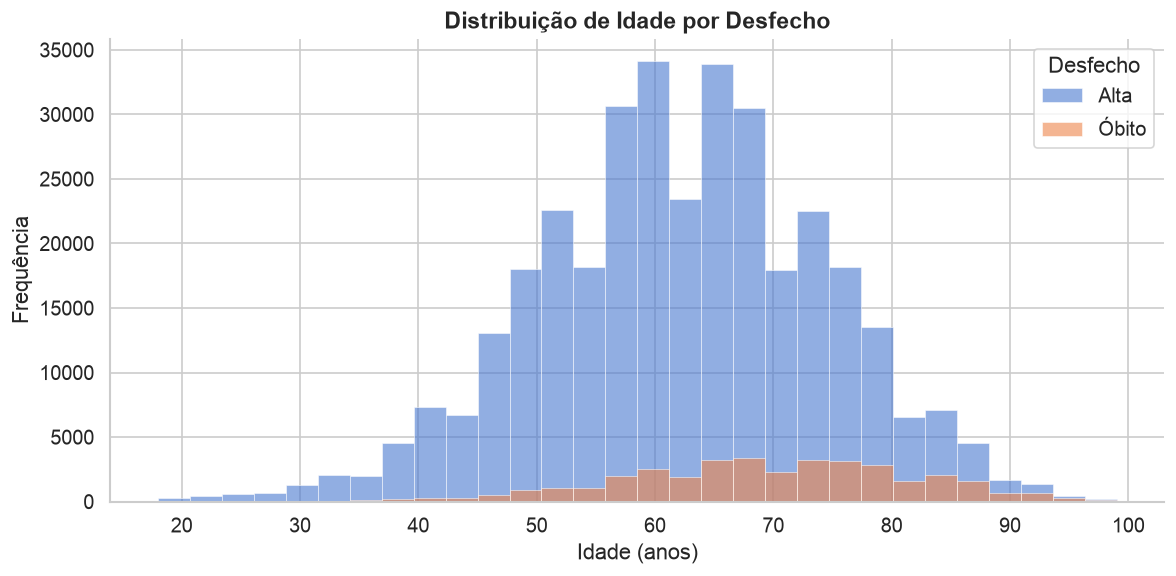

Figura salva em reports/figures/hist_idade.png


In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

for desfecho, grp in df.groupby('desfecho_label'):
    ax.hist(
        grp['idade'].dropna(), bins=30,
        alpha=0.6, label=desfecho, edgecolor='white', linewidth=0.5
    )

ax.set_title('Distribuição de Idade por Desfecho', fontsize=14, fontweight='bold')
ax.set_xlabel('Idade (anos)')
ax.set_ylabel('Frequência')
ax.legend(title='Desfecho')
sns.despine()
plt.tight_layout()
plt.savefig(FIG_PATH / 'hist_idade.png', dpi=150)
plt.show()
print('Figura salva em reports/figures/hist_idade.png')

### 5.2 Boxplot de Tempo de Permanência por Desfecho

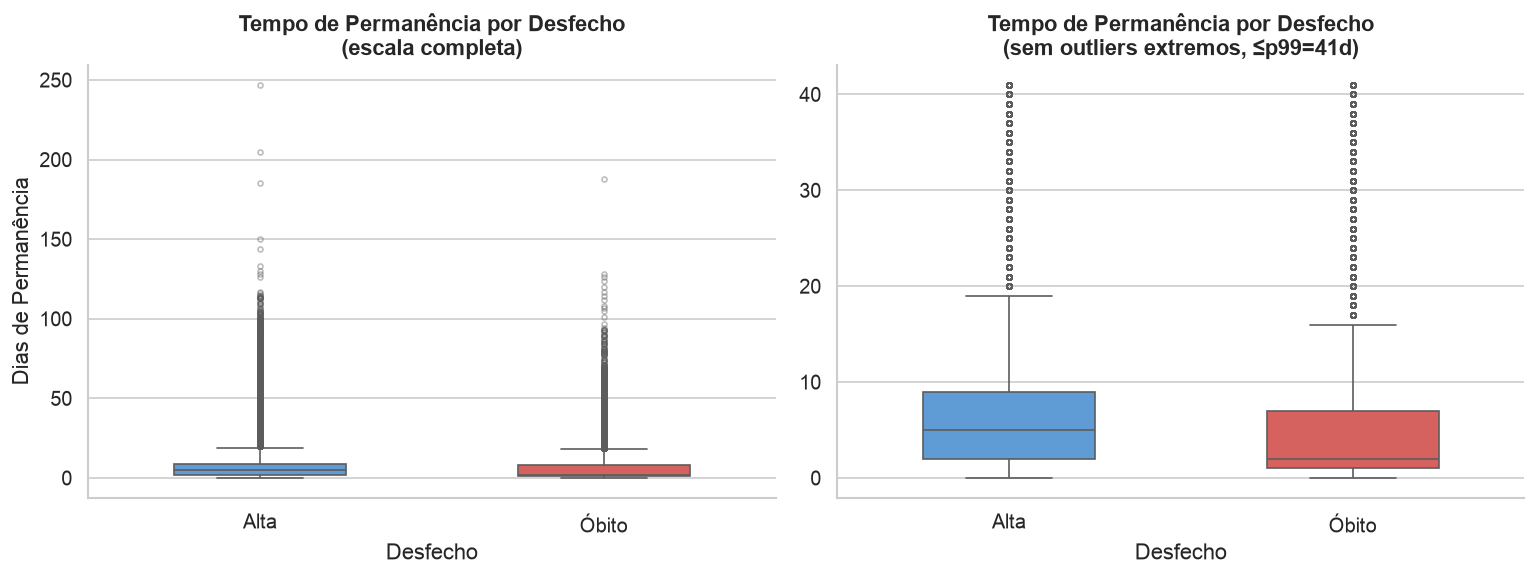

Figura salva em reports/figures/boxplot_permanencia_desfecho.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Escala completa
sns.boxplot(
    data=df, x='desfecho_label', y='dias_permanencia',
    hue='desfecho_label', palette={'Alta': '#4C9BE8', 'Óbito': '#E8504C'},
    width=0.5, legend=False, flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=axes[0]
)
axes[0].set_title('Tempo de Permanência por Desfecho\n(escala completa)', fontweight='bold')
axes[0].set_xlabel('Desfecho')
axes[0].set_ylabel('Dias de Permanência')

# Sem outliers extremos (p99)
p99 = df['dias_permanencia'].quantile(0.99)
df_trim = df[df['dias_permanencia'] <= p99]
sns.boxplot(
    data=df_trim, x='desfecho_label', y='dias_permanencia',
    hue='desfecho_label', palette={'Alta': '#4C9BE8', 'Óbito': '#E8504C'},
    width=0.5, legend=False, flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=axes[1]
)
axes[1].set_title(f'Tempo de Permanência por Desfecho\n(sem outliers extremos, ≤p99={p99:.0f}d)', fontweight='bold')
axes[1].set_xlabel('Desfecho')
axes[1].set_ylabel('')

sns.despine()
plt.tight_layout()
plt.savefig(FIG_PATH / 'boxplot_permanencia_desfecho.png', dpi=150)
plt.show()
print('Figura salva em reports/figures/boxplot_permanencia_desfecho.png')

### 5.3 Gráfico de Barras – Letalidade por Faixa Etária

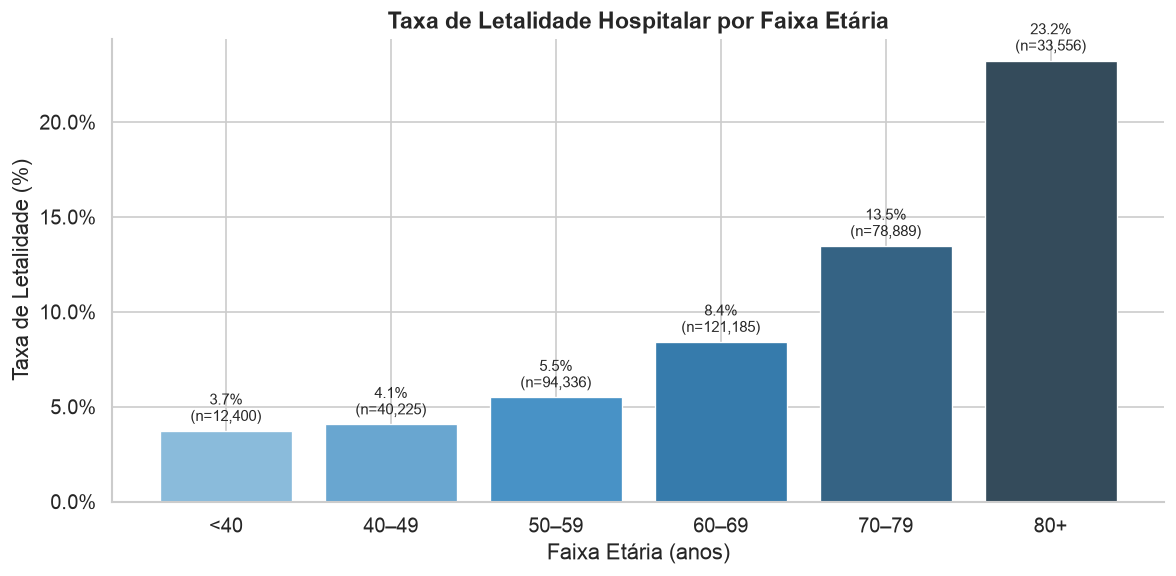

Figura salva em reports/figures/barras_letali_faixa_etaria.png


In [19]:
letali_fx = (
    df.groupby('faixa_etaria', observed=True)['indicador_obito']
    .agg(n_total='count', n_obitos='sum')
    .assign(taxa_letali=lambda x: (x['n_obitos'] / x['n_total']) * 100)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    letali_fx['faixa_etaria'].astype(str),
    letali_fx['taxa_letali'],
    color=sns.color_palette('Blues_d', len(letali_fx)),
    edgecolor='white', linewidth=0.8
)

# Rótulos nas barras
for bar, (_, row) in zip(bars, letali_fx.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{row['taxa_letali']:.1f}%\n(n={int(row['n_total']):,})",
        ha='center', va='bottom', fontsize=9
    )

ax.set_title('Taxa de Letalidade Hospitalar por Faixa Etária', fontsize=14, fontweight='bold')
ax.set_xlabel('Faixa Etária (anos)')
ax.set_ylabel('Taxa de Letalidade (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
sns.despine()
plt.tight_layout()
plt.savefig(FIG_PATH / 'barras_letali_faixa_etaria.png', dpi=150)
plt.show()
print('Figura salva em reports/figures/barras_letali_faixa_etaria.png')

### 5.4 Mapa de Calor – Correlação entre Variáveis Numéricas

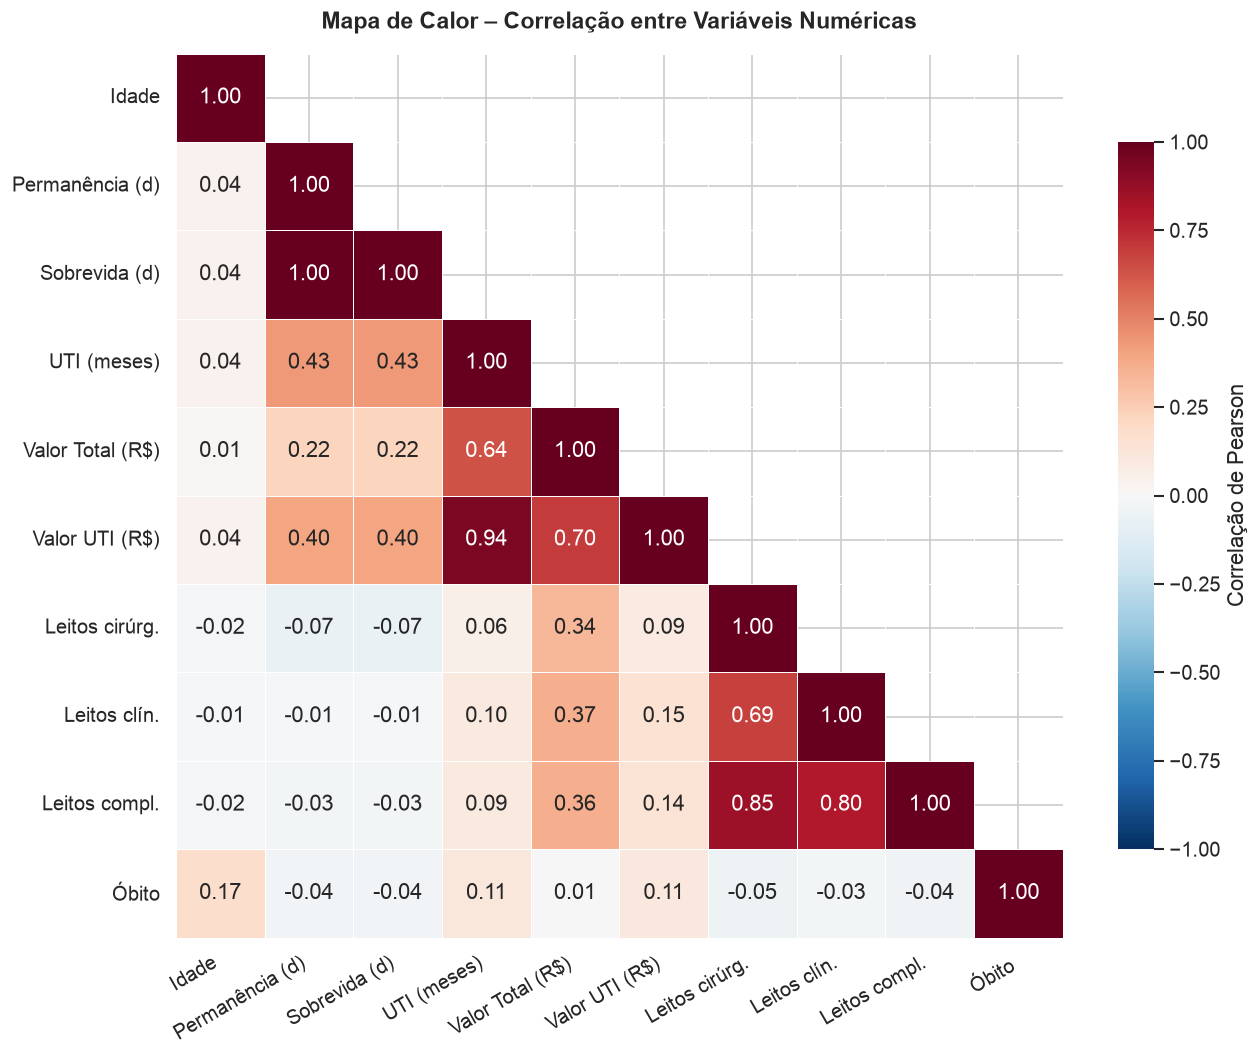

Figura salva em reports/figures/heatmap_correlacao.png


In [20]:
vars_num = [
    'idade', 'dias_permanencia', 'tempo_sobrevida',
    'uti_mes_total', 'valor_total', 'valor_uti',
    'qtd_leitos_cirurgicos', 'qtd_leitos_clinicos',
    'qtd_leitos_complementares', 'indicador_obito'
]
# Filtra apenas colunas que existem na base (segurança)
vars_num = [c for c in vars_num if c in df.columns]

# Converte para numérico (algumas colunas vêm como string)
for c in vars_num:
    df[c] = pd.to_numeric(df[c], errors='coerce')

corr = df[vars_num].corr()

# Rótulos legíveis
labels = {
    'idade':                    'Idade',
    'dias_permanencia':         'Permanência (d)',
    'tempo_sobrevida':          'Sobrevida (d)',
    'uti_mes_total':            'UTI (meses)',
    'valor_total':              'Valor Total (R$)',
    'valor_uti':                'Valor UTI (R$)',
    'qtd_leitos_cirurgicos':    'Leitos cirúrg.',
    'qtd_leitos_clinicos':      'Leitos clín.',
    'qtd_leitos_complementares':'Leitos compl.',
    'indicador_obito':          'Óbito'
}
corr.rename(index=labels, columns=labels, inplace=True)

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': 'Correlação de Pearson'},
    ax=ax
)
ax.set_title('Mapa de Calor – Correlação entre Variáveis Numéricas',
             fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_PATH / 'heatmap_correlacao.png', dpi=150)
plt.show()
print('Figura salva em reports/figures/heatmap_correlacao.png')


---
## Resumo das Análises

| Item | Resultado |
|------|----------|
| Internações na base | ver célula 2 |
| Hospitais únicos (CNES) | ver célula 2 |
| Taxa de letalidade | ver célula 2 |
| Figura 1 – Histograma de Idade | `reports/figures/hist_idade.png` |
| Figura 2 – Boxplot Permanência × Desfecho | `reports/figures/boxplot_permanencia_desfecho.png` |
| Figura 3 – Letalidade por Faixa Etária | `reports/figures/barras_letali_faixa_etaria.png` |
| Figura 4 – Mapa de Calor Correlação | `reports/figures/heatmap_correlacao.png` |

> **Próximos passos:** notebook `04_modelagem.ipynb` – construção e avaliação dos modelos preditivos.